# 🛒 Smart E-Commerce Intelligence System
### Interactive Machine Learning Workshop — Colab Edition

**Goal:** Use one clean, synthetic e-commerce customer dataset to learn four core ML models:

1. **Linear Regression** — predict annual customer spending
2. **Logistic Regression** — predict customer churn
3. **Decision Tree** — understand rule-based predictions
4. **Random Forest** — understand ensemble learning

The project follows the teaching documentation: the business questions are **"How much will a customer spend?"** and **"Will a customer churn?"**

> **Important:** This is a synthetic educational dataset. Its results are for learning and should not be treated as real business evidence.

## 1. Install / import the libraries

We will use **Pandas** and **NumPy** for data handling, **Matplotlib/Seaborn** for visualization, and **Scikit-learn** for machine learning.

Run this cell first.

### 1.1 Import Pandas and NumPy

These libraries help us work with tables and numerical data.


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [30]:
# ==========================================================
# Topic: Pandas and NumPy
# Description:
# Pandas is used to work with table-like data.
# NumPy is used for numerical calculations and arrays.
#
# Key idea:
# Pandas handles the dataset, while NumPy helps with numerical operations.
# ==========================================================

import pandas as pd

import numpy as np

print("Pandas and NumPy imported successfully!")


Pandas and NumPy imported successfully!


### 1.2 Import visualization libraries

We use charts to understand patterns before building models.


In [31]:
# ==========================================================
# Topic: Matplotlib and Seaborn
# Description:
# Matplotlib and Seaborn are used to create charts and graphs.
# These charts help us understand patterns in the customer data.
#
# Key idea:
# Visualization helps us understand the data before building ML models.
# ==========================================================

import matplotlib.pyplot as plt

import seaborn as sns

sns.set_theme(style="whitegrid")

print("Visualization libraries imported successfully!")


Visualization libraries imported successfully!


### 1.3 Import tools for splitting and preprocessing

These tools prepare the data in a way that ML models can understand.


In [32]:
# ==========================================================
# Topic: Data Preparation Tools
# Description:
# These Scikit-learn tools help us split data and prepare different types of columns.
# OneHotEncoder converts categories into numbers.
# StandardScaler scales numerical values.
# ColumnTransformer and Pipeline connect these steps together.
#
# Key idea:
# ML models need the input data in a suitable numerical format.
# ==========================================================

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.pipeline import Pipeline

print("Data preparation tools imported successfully!")


Data preparation tools imported successfully!


### 1.4 Import the four main model families

We will mainly focus on Linear Regression, Logistic Regression, Decision Trees, and Random Forests.


In [33]:
# ==========================================================
# Topic: Machine Learning Models
# Description:
# These are the main models used in this project.
# Regression models predict a numerical value.
# Classification models predict a class such as 0 or 1.
#
# Key idea:
# We will use Linear Regression, Logistic Regression, Decision Trees, and Random Forests.
# ==========================================================

from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

print("Machine learning models imported successfully!")


Machine learning models imported successfully!


### 1.5 Import evaluation metrics

Metrics help us measure how well each model performs.


In [34]:
# ==========================================================
# Topic: Evaluation Metrics
# Description:
# These metrics measure how well our ML models perform.
# Regression uses metrics such as MAE, RMSE, and R².
# Classification uses metrics such as Accuracy, Precision, Recall, F1-score, and ROC-AUC.
#
# Key idea:
# A model should be evaluated on data it did not use for training.
# ==========================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Evaluation metrics imported successfully!")


Evaluation metrics imported successfully!


## 2. Load the prepared 200-customer dataset

The CSV is already clean for this workshop: 200 customers, 18 columns, no missing values, and no duplicate rows.


### 2.1 Upload the CSV


In [35]:
# ==========================================================
# Topic: Uploading the Dataset
# Description:
# This opens the Google Colab file picker.
# Select the prepared e-commerce CSV file.
#
# Key idea:
# The uploaded file will be available to Python through the uploaded dictionary.
# ==========================================================

from google.colab import files

uploaded = files.upload()


Saving ecommerce_customers_200_clean.csv to ecommerce_customers_200_clean (1).csv


### 2.2 Read the CSV into a DataFrame


In [36]:
# ==========================================================
# Topic: Reading a CSV File
# Description:
# The uploaded CSV file is read into a Pandas DataFrame.
# A DataFrame is a table with rows and columns.
#
# Key idea:
# The variable df now contains our customer dataset.
# ==========================================================

# The uploaded variable contains two files. We explicitly choose the customer data file.
file_name = 'ecommerce_customers_200_clean.csv'

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (200, 18)


### 2.3 Look at the first few customers


In [37]:
# ==========================================================
# Topic: Viewing the First Rows
# Description:
# head() displays the first five rows of the DataFrame.
# It gives us a quick look at the structure and values in the dataset.
#
# Key idea:
# Always inspect a dataset after loading it.
# ==========================================================

display(df.head())


,Customer_ID,Age,Gender,City_Tier,Income,Tenure_Months,Visits_Per_Month,Products_Bought,Avg_Order_Value,Discount_Usage_Rate,Cart_Abandonment_Rate,Reviews_Given,Support_Tickets,Days_Since_Last_Purchase,Membership_Type,Preferred_Category,Annual_Spending,Churn
0,CUST0001,22,Female,Tier 3,101500,104,4.2,13,4300,0.119,0.668,6,4,69,Basic,Electronics,55531,1
1,CUST0002,59,Female,Tier 1,79700,58,11.7,17,3230,0.194,0.503,6,1,0,NaN,Fashion,38129,0
2,CUST0003,52,Male,Tier 2,90900,114,11.5,23,4650,0.435,0.579,4,4,81,NaN,Grocery,55590,0
3,CUST0004,41,Other,Tier 2,66300,120,22.8,18,3010,0.017,0.380,4,0,25,Basic,Fashion,74415,0
4,CUST0005,40,Female,Tier 3,62400,71,17.4,16,5530,0.400,0.521,7,3,4,Basic,Grocery,55308,0


## 3. Understand the dataset


### 3.1 Check rows and columns


In [38]:
# ==========================================================
# Topic: Dataset Shape
# Description:
# shape tells us the number of rows and columns.
# The first value is the number of rows and the second is the number of columns.
#
# Key idea:
# Our project uses 200 customers and 18 columns.
# ==========================================================

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 200
Columns: 18


### 3.2 See all column names


In [39]:
# ==========================================================
# Topic: Dataset Column Names
# Description:
# columns gives all column names in the DataFrame.
# tolist() converts them into a normal Python list.
#
# Key idea:
# Knowing the column names helps us select features and targets later.
# ==========================================================

print(df.columns.tolist())


['Customer_ID', 'Age', 'Gender', 'City_Tier', 'Income', 'Tenure_Months', 'Visits_Per_Month', 'Products_Bought', 'Avg_Order_Value', 'Discount_Usage_Rate', 'Cart_Abandonment_Rate', 'Reviews_Given', 'Support_Tickets', 'Days_Since_Last_Purchase', 'Membership_Type', 'Preferred_Category', 'Annual_Spending', 'Churn']


### 3.3 Check data types


In [40]:
# ==========================================================
# Topic: Data Types
# Description:
# dtypes tells us the data type of every column.
# Some columns contain numbers, while others contain categories or text.
#
# Key idea:
# The type of a column helps us decide how it should be handled by an ML model.
# ==========================================================

display(df.dtypes.to_frame("Data Type"))


,Data Type
Customer_ID,object
Age,int64
Gender,object
City_Tier,object
Income,int64
Tenure_Months,int64
Visits_Per_Month,float64
Products_Bought,int64
Avg_Order_Value,int64
Discount_Usage_Rate,float64


### 3.4 Check for missing values


In [41]:
# ==========================================================
# Topic: Missing Values
# Description:
# isna() identifies missing values.
# sum() counts the missing values in each column.
#
# Key idea:
# This dataset is already clean, so the expected missing-value count is zero.
# ==========================================================

display(df.isna().sum().to_frame("Missing Values"))


,Missing Values
Customer_ID,0
Age,0
Gender,0
City_Tier,0
Income,0
Tenure_Months,0
Visits_Per_Month,0
Products_Bought,0
Avg_Order_Value,0
Discount_Usage_Rate,0


### 3.5 Check for duplicate rows


In [42]:
# ==========================================================
# Topic: Duplicate Rows
# Description:
# duplicated() checks whether a complete row appears more than once.
# sum() counts the duplicate rows.
#
# Key idea:
# The prepared dataset contains no duplicate rows.
# ==========================================================

print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


### 3.6 View summary statistics


In [43]:
# ==========================================================
# Topic: Summary Statistics
# Description:
# describe() gives useful summary information about the dataset.
# For numerical columns it shows values such as mean, minimum, and maximum.
# include='all' also includes categorical columns.
#
# Key idea:
# Summary statistics help us understand the data before modelling.
# ==========================================================

display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer_ID,200,200,CUST0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,200.0,NaN,NaN,NaN,44.475,14.575031,18.0,32.75,44.0,58.0,70.0
Gender,200,3,Female,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City_Tier,200,3,Tier 2,78,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,200.0,NaN,NaN,NaN,67877.0,29518.284445,15000.0,46700.0,68800.0,87275.0,155500.0
Tenure_Months,200.0,NaN,NaN,NaN,56.765,35.55334,1.0,27.5,55.5,89.0,120.0
Visits_Per_Month,200.0,NaN,NaN,NaN,11.73,5.75056,0.0,7.875,11.85,14.75,30.0
Products_Bought,200.0,NaN,NaN,NaN,14.98,4.097996,6.0,12.0,14.0,17.0,30.0
Avg_Order_Value,200.0,NaN,NaN,NaN,4734.1,1846.289554,200.0,3615.0,4730.0,5957.5,10590.0
Discount_Usage_Rate,200.0,NaN,NaN,NaN,0.37593,0.184237,0.017,0.22625,0.3565,0.5095,0.852


## 4. Identify the two business questions


### 4.1 Regression target


In [44]:
# ==========================================================
# Topic: Regression Target
# Description:
# A regression problem predicts a continuous numerical value.
# In this project, the value we want to predict is Annual_Spending.
#
# Key idea:
# Annual_Spending is the target variable for regression.
# ==========================================================

regression_target = "Annual_Spending"

print("Regression target:", regression_target)


Regression target: Annual_Spending


### 4.2 Classification target


In [45]:
# ==========================================================
# Topic: Classification Target
# Description:
# A classification problem predicts a category or class.
# In this project, Churn contains 0 or 1.
#
# Key idea:
# Churn is the target variable for classification.
# ==========================================================

classification_target = "Churn"

print("Classification target:", classification_target)


Classification target: Churn


### 4.3 Check the churn classes


In [46]:
# ==========================================================
# Topic: Checking Churn Classes
# Description:
# value_counts() counts how many customers belong to each churn class.
# 0 represents No Churn and 1 represents Churn.
#
# Key idea:
# This helps us understand the distribution of the classification target.
# ==========================================================

display(
    df["Churn"]
    .value_counts()
    .rename(index={0: "No Churn", 1: "Churn"})
)


,count
Churn,
No Churn,145
Churn,55


## 5. Quick visual exploration


### 5.1 Annual spending distribution


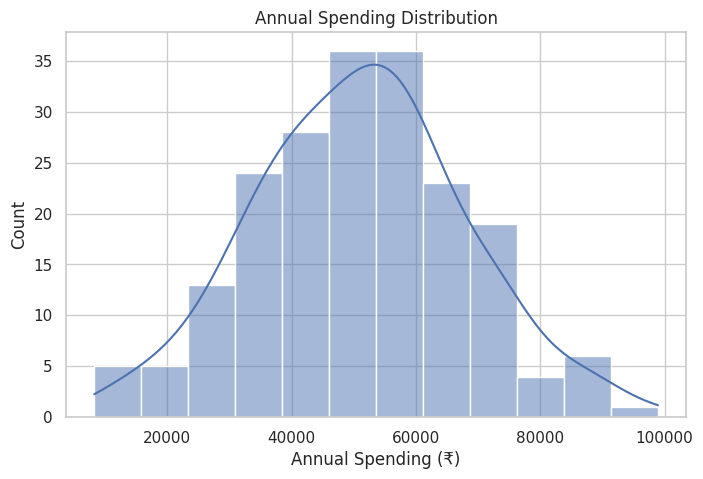

In [47]:
# ==========================================================
# Topic: Annual Spending Distribution
# Description:
# A histogram shows how Annual_Spending values are distributed.
# The KDE curve gives an additional view of the distribution.
#
# Key idea:
# A distribution plot helps us see the range and pattern of customer spending.
# ==========================================================

plt.figure(figsize=(8, 5))
sns.histplot(df["Annual_Spending"], kde=True)
plt.title("Annual Spending Distribution")
plt.xlabel("Annual Spending (₹)")
plt.show()


### 5.2 Income vs annual spending


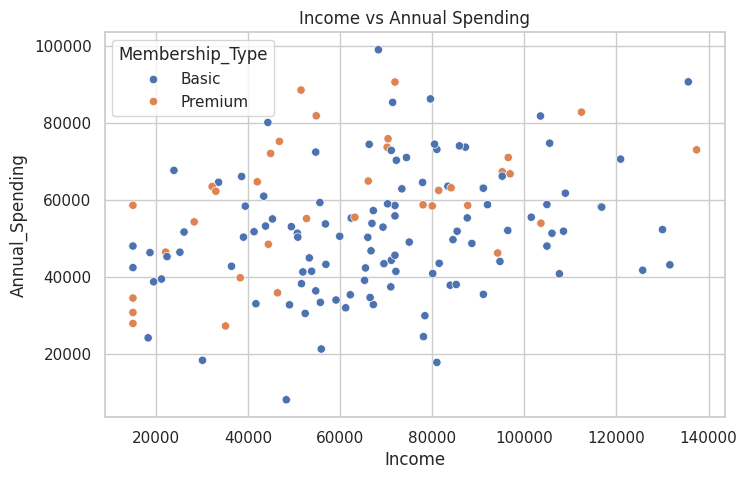

In [48]:
# ==========================================================
# Topic: Income vs Annual Spending
# Description:
# A scatter plot shows the relationship between Income and Annual_Spending.
# Each point represents one customer.
# The colour separates customers by Membership_Type.
#
# Key idea:
# Charts can help us notice possible relationships between variables.
# ==========================================================

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Income",
    y="Annual_Spending",
    hue="Membership_Type"
)
plt.title("Income vs Annual Spending")
plt.show()


### 5.3 Churn distribution


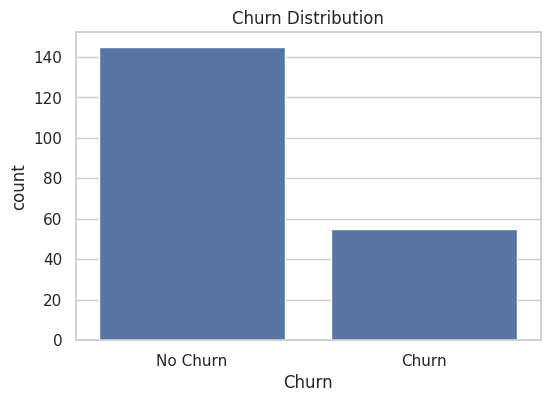

In [49]:
# ==========================================================
# Topic: Churn Distribution
# Description:
# A count plot shows the number of customers in each churn class.
#
# Key idea:
# We can quickly see how many customers are labelled No Churn and Churn.
# ==========================================================

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.title("Churn Distribution")
plt.show()


### 5.4 Annual spending by membership


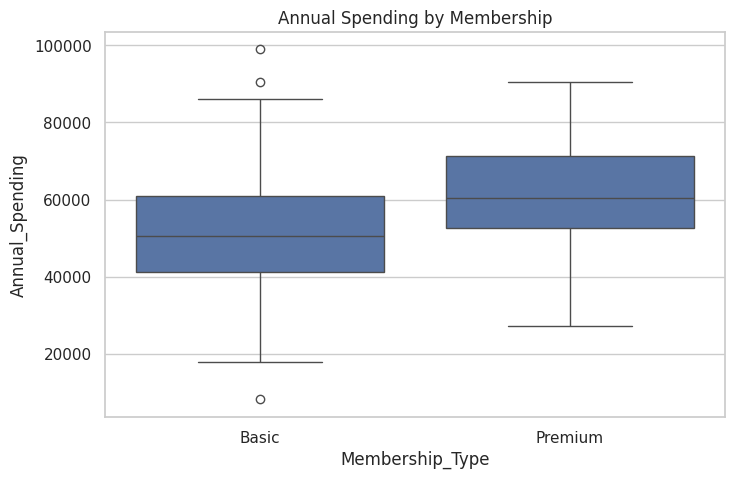

In [50]:
# ==========================================================
# Topic: Spending by Membership
# Description:
# A boxplot compares Annual_Spending across different membership types.
# It shows the distribution and spread of spending for each group.
#
# Key idea:
# Grouping the data can reveal differences between customer categories.
# ==========================================================

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Membership_Type", y="Annual_Spending")
plt.title("Annual Spending by Membership")
plt.show()


# PART A — REGRESSION

## 6. Prepare the data for predicting Annual Spending


### 6.1 Choose the input features


In [51]:
# ==========================================================
# Topic: Selecting Regression Features
# Description:
# X_reg contains the information given to the regression model.
# The target column Annual_Spending is not included because it is the value we want to predict.
# Customer_ID is also excluded because it is only an identifier.
#
# Key idea:
# X contains the input features used by the model.
# ==========================================================

regression_features = [
    "Age", "Gender", "City_Tier", "Income", "Tenure_Months",
    "Visits_Per_Month", "Products_Bought", "Avg_Order_Value",
    "Discount_Usage_Rate", "Cart_Abandonment_Rate", "Reviews_Given",
    "Support_Tickets", "Days_Since_Last_Purchase",
    "Membership_Type", "Preferred_Category"
]

X_reg = df[regression_features]

print("Number of input features:", X_reg.shape[1])
display(X_reg.head())


Number of input features: 15


,Age,Gender,City_Tier,Income,Tenure_Months,Visits_Per_Month,Products_Bought,Avg_Order_Value,Discount_Usage_Rate,Cart_Abandonment_Rate,Reviews_Given,Support_Tickets,Days_Since_Last_Purchase,Membership_Type,Preferred_Category
0,22,Female,Tier 3,101500,104,4.2,13,4300,0.119,0.668,6,4,69,Basic,Electronics
1,59,Female,Tier 1,79700,58,11.7,17,3230,0.194,0.503,6,1,0,NaN,Fashion
2,52,Male,Tier 2,90900,114,11.5,23,4650,0.435,0.579,4,4,81,NaN,Grocery
3,41,Other,Tier 2,66300,120,22.8,18,3010,0.017,0.380,4,0,25,Basic,Fashion
4,40,Female,Tier 3,62400,71,17.4,16,5530,0.400,0.521,7,3,4,Basic,Grocery


### 6.2 Choose the regression target


In [52]:
# ==========================================================
# Topic: Selecting the Regression Target
# Description:
# y_reg contains the correct Annual_Spending values.
# The model learns to predict these values from X_reg.
#
# Key idea:
# In supervised learning, y contains the answers used during training.
# ==========================================================

y_reg = df["Annual_Spending"]

print("Regression target:")
display(y_reg.head())


Regression target:


,Annual_Spending
0,55531
1,38129
2,55590
3,74415
4,55308


### 6.3 Separate numeric and categorical features


In [53]:
# ==========================================================
# Topic: Numeric and Categorical Features
# Description:
# Numeric features contain numerical values.
# Categorical features contain groups or labels such as Gender and Membership_Type.
#
# Key idea:
# Different types of features can require different preparation before modelling.
# ==========================================================

categorical_features = [
    "Gender", "City_Tier", "Membership_Type", "Preferred_Category"
]

numeric_features = [
    "Age", "Income", "Tenure_Months", "Visits_Per_Month",
    "Products_Bought", "Avg_Order_Value", "Discount_Usage_Rate",
    "Cart_Abandonment_Rate", "Reviews_Given", "Support_Tickets",
    "Days_Since_Last_Purchase"
]

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)


Categorical features: ['Gender', 'City_Tier', 'Membership_Type', 'Preferred_Category']
Numeric features: ['Age', 'Income', 'Tenure_Months', 'Visits_Per_Month', 'Products_Bought', 'Avg_Order_Value', 'Discount_Usage_Rate', 'Cart_Abandonment_Rate', 'Reviews_Given', 'Support_Tickets', 'Days_Since_Last_Purchase']


In [54]:
# ==========================================================
# Topic: Create Preprocessing Pipeline
# Description:
# Numeric columns are scaled using StandardScaler.
# Categorical columns are converted into numerical columns
# using OneHotEncoder.
#
# Key idea:
# The preprocessor prepares different types of features
# before they are given to the ML model.
# ==========================================================

preprocessor = ColumnTransformer([
    (
        "num",
        StandardScaler(),
        numeric_features
    ),
    (
        "cat",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_features
    )
])

print("Preprocessor created successfully!")

Preprocessor created successfully!


### 6.5 Split into training and testing data


In [55]:
# ==========================================================
# Topic: Training and Testing Split
# Description:
# The dataset is divided into training and testing parts.
# 80% is used to train the model and 20% is used to test it.
#
# Key idea:
# The test data represents customers the model has not seen during training.
# ==========================================================

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train_reg))
print("Testing rows:", len(X_test_reg))


Training rows: 160
Testing rows: 40


## 7. Model 1 — Linear Regression


### 7.1 Create the Linear Regression pipeline


In [56]:
# ==========================================================
# Topic: Linear Regression Pipeline
# Description:
# Pipeline connects preprocessing and Linear Regression into one workflow.
# The preprocessing happens first, followed by model training.
#
# Key idea:
# Linear Regression learns a mathematical relationship between the input features and Annual_Spending.
# ==========================================================

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

print("Linear Regression pipeline created.")


Linear Regression pipeline created.


### 7.2 Train the Linear Regression model


In [57]:
# ==========================================================
# Topic: Training Linear Regression
# Description:
# fit() trains the Linear Regression model using the training data.
# The model learns patterns from X_train_reg and y_train_reg.
#
# Key idea:
# Training means learning the relationship between inputs and the target.
# ==========================================================

linear_model.fit(X_train_reg, y_train_reg)

print("Linear Regression training completed.")


Linear Regression training completed.


### 7.3 Make predictions


In [58]:
# ==========================================================
# Topic: Linear Regression Predictions
# Description:
# predict() uses the trained model to estimate Annual_Spending for the test customers.
#
# Key idea:
# The predicted values can now be compared with the actual values.
# ==========================================================

linear_pred = linear_model.predict(X_test_reg)

display(pd.DataFrame({
    "Actual": y_test_reg.values,
    "Predicted": linear_pred
}).head(10))


,Actual,Predicted
0,43807,46116.054260
1,46491,41678.574198
2,34084,53227.323582
3,38098,50232.996544
4,55355,50710.986771
5,21389,44382.984722
6,40946,41684.309918
7,41533,37992.278718
8,63157,65115.328308
9,41794,38901.145860


### 7.4 Evaluate Linear Regression


In [59]:
# ==========================================================
# Topic: Evaluating Linear Regression
# Description:
# MAE measures the average absolute prediction error.
# RMSE measures prediction error while giving larger errors more weight.
# R² shows how much variation in the target is explained by the model.
#
# Key idea:
# Lower MAE and RMSE are generally better, while a higher R² indicates more explained variation.
# ==========================================================

linear_mae = mean_absolute_error(y_test_reg, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test_reg, linear_pred))
linear_r2 = r2_score(y_test_reg, linear_pred)

print(f"MAE  : ₹{linear_mae:,.2f}")
print(f"RMSE : ₹{linear_rmse:,.2f}")
print(f"R²   : {linear_r2:.3f}")


MAE  : ₹9,330.49
RMSE : ₹12,029.78
R²   : 0.462


### 7.5 Visualize actual vs predicted spending


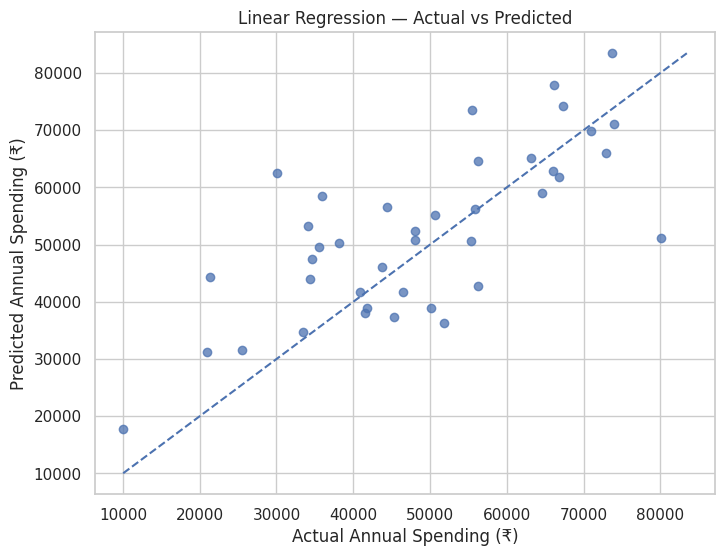

In [60]:
# ==========================================================
# Topic: Actual vs Predicted Plot
# Description:
# This scatter plot compares the real Annual_Spending values with the model predictions.
# The dashed diagonal line represents perfect predictions.
#
# Key idea:
# Points closer to the diagonal line indicate predictions closer to the actual values.
# ==========================================================

plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, linear_pred, alpha=0.75)

min_value = min(y_test_reg.min(), linear_pred.min())
max_value = max(y_test_reg.max(), linear_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Annual Spending (₹)")
plt.ylabel("Predicted Annual Spending (₹)")
plt.title("Linear Regression — Actual vs Predicted")
plt.show()


## 8. Model 2 — Decision Tree Regressor


### 8.1 Create the Decision Tree


In [61]:
# ==========================================================
# Topic: Decision Tree Regressor
# Description:
# A Decision Tree Regressor learns a series of rules to predict a numerical value.
# max_depth limits how deep the tree can grow.
#
# Key idea:
# A decision tree makes predictions by following learned if-then style rules.
# ==========================================================

tree_reg_model = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ], remainder="passthrough")),
    ("model", DecisionTreeRegressor(max_depth=5, random_state=42))
])

print("Decision Tree Regressor created.")


Decision Tree Regressor created.


### 8.2 Train and predict


In [62]:
# ==========================================================
# Topic: Training the Decision Tree
# Description:
# fit() trains the Decision Tree using the training customers.
# predict() then produces Annual_Spending predictions for the test customers.
#
# Key idea:
# The model learns from training data and predicts on unseen test data.
# ==========================================================

tree_reg_model.fit(X_train_reg, y_train_reg)

tree_pred = tree_reg_model.predict(X_test_reg)

print("Predictions created:", len(tree_pred))


Predictions created: 40


### 8.3 Evaluate the Decision Tree


In [63]:
# ==========================================================
# Topic: Evaluating the Decision Tree
# Description:
# The same regression metrics are calculated for the Decision Tree.
# This allows us to compare it fairly with Linear Regression.
#
# Key idea:
# Using the same test data and metrics makes model comparison meaningful.
# ==========================================================

tree_mae = mean_absolute_error(y_test_reg, tree_pred)
tree_rmse = np.sqrt(mean_squared_error(y_test_reg, tree_pred))
tree_r2 = r2_score(y_test_reg, tree_pred)

print(f"MAE  : ₹{tree_mae:,.2f}")
print(f"RMSE : ₹{tree_rmse:,.2f}")
print(f"R²   : {tree_r2:.3f}")


MAE  : ₹12,052.61
RMSE : ₹15,783.07
R²   : 0.074


## 9. Model 3 — Random Forest Regressor


### 9.1 Create the Random Forest


In [64]:
# ==========================================================
# Topic: Random Forest Regressor
# Description:
# A Random Forest combines many Decision Trees.
# n_estimators=200 means the forest contains 200 trees.
#
# Key idea:
# Combining many trees can capture more complex patterns than a single tree.
# ==========================================================

forest_reg_model = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ], remainder="passthrough")),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        random_state=42
    ))
])

print("Random Forest Regressor created.")


Random Forest Regressor created.


### 9.2 Train and predict


In [65]:
# ==========================================================
# Topic: Training the Random Forest
# Description:
# fit() trains all the trees in the Random Forest using the training data.
# predict() generates spending predictions for the test customers.
#
# Key idea:
# The forest combines the information learned by many decision trees.
# ==========================================================

forest_reg_model.fit(X_train_reg, y_train_reg)

forest_pred = forest_reg_model.predict(X_test_reg)

print("Predictions created:", len(forest_pred))


Predictions created: 40


### 9.3 Evaluate the Random Forest


In [66]:
# ==========================================================
# Topic: Evaluating the Random Forest
# Description:
# MAE, RMSE, and R² are calculated for the Random Forest.
# These values can be compared with the other regression models.
#
# Key idea:
# The model is evaluated using the same test set as the other models.
# ==========================================================

forest_mae = mean_absolute_error(y_test_reg, forest_pred)
forest_rmse = np.sqrt(mean_squared_error(y_test_reg, forest_pred))
forest_r2 = r2_score(y_test_reg, forest_pred)

print(f"MAE  : ₹{forest_mae:,.2f}")
print(f"RMSE : ₹{forest_rmse:,.2f}")
print(f"R²   : {forest_r2:.3f}")


MAE  : ₹10,672.47
RMSE : ₹13,136.41
R²   : 0.359


## 10. Compare the three regression models


In [67]:
# ==========================================================
# Topic: Regression Model Comparison
# Description:
# The results from Linear Regression, Decision Tree, and Random Forest are placed into one table.
#
# Key idea:
# A comparison table makes it easier to study how the different models performed.
# ==========================================================

regression_results = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MAE": linear_mae,
        "RMSE": linear_rmse,
        "R²": linear_r2
    },
    {
        "Model": "Decision Tree",
        "MAE": tree_mae,
        "RMSE": tree_rmse,
        "R²": tree_r2
    },
    {
        "Model": "Random Forest",
        "MAE": forest_mae,
        "RMSE": forest_rmse,
        "R²": forest_r2
    }
])

display(regression_results.round(3))


,Model,MAE,RMSE,R²
0,Linear Regression,9330.492,12029.780,0.462
1,Decision Tree,12052.614,15783.072,0.074
2,Random Forest,10672.471,13136.413,0.359


## 11. Regression residuals


A residual is **Actual − Predicted**. It shows how far a prediction was from the real value.


In [68]:
# ==========================================================
# Topic: Regression Residuals
# Description:
# A residual is the difference between the actual value and the predicted value.
# Residual = Actual - Predicted.
#
# Key idea:
# Residuals show the size and direction of prediction errors.
# ==========================================================

residuals = y_test_reg - forest_pred

display(residuals.head())


,Annual_Spending
95,-5360.889875
15,9934.737943
30,-19449.148977
158,-12677.292405
128,7176.306589


### 11.1 Plot the residuals


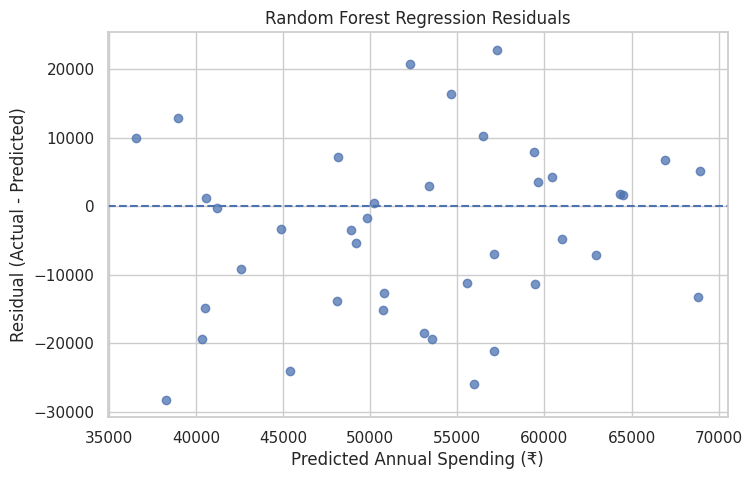

In [69]:
# ==========================================================
# Topic: Regression Residual Plot
# Description:
# This plot shows residuals against predicted Annual_Spending.
# A residual near zero means the prediction is close to the actual value.
#
# Key idea:
# The plot helps us visually inspect the model's prediction errors.
# ==========================================================

plt.figure(figsize=(8, 5))
plt.scatter(forest_pred, residuals, alpha=0.75)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Annual Spending (₹)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Random Forest Regression Residuals")
plt.show()


# PART B — CLASSIFICATION

## 12. Prepare the data for Churn prediction


### 12.1 Choose the classification features


In [70]:
# ==========================================================
# Topic: Selecting Classification Features
# Description:
# X_clf contains the customer information used to predict Churn.
# The Churn column is not included because it is the target.
#
# Key idea:
# The input features describe the customer, while the target contains the answer.
# ==========================================================

classification_features = regression_features.copy()

X_clf = df[classification_features]
print("Number of input features:", X_clf.shape[1])


Number of input features: 15


### 12.2 Choose the classification target


In [71]:
# ==========================================================
# Topic: Selecting the Classification Target
# Description:
# y_clf contains the Churn labels.
# 0 means No Churn and 1 means Churn.
#
# Key idea:
# The classification model learns to predict these two classes.
# ==========================================================

y_clf = df["Churn"]

display(y_clf.head())


,Churn
0,1
1,0
2,0
3,0
4,0


### 12.3 Split classification data


In [72]:
# ==========================================================
# Topic: Classification Train-Test Split
# Description:
# The data is divided into training and testing sets.
# stratify=y_clf keeps the class proportion similar in both sets.
#
# Key idea:
# Stratification is useful when we want both sets to represent the target classes fairly.
# ==========================================================

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

print("Training rows:", len(X_train_clf))
print("Testing rows:", len(X_test_clf))


Training rows: 160
Testing rows: 40


## 13. Model 4 — Logistic Regression


### 13.1 Create the Logistic Regression pipeline


In [73]:
# ==========================================================
# Topic: Logistic Regression Pipeline
# Description:
# Logistic Regression is a classification algorithm.
# The Pipeline first prepares the features and then trains the classifier.
#
# Key idea:
# Logistic Regression estimates the probability of belonging to a class.
# ==========================================================

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

print("Logistic Regression pipeline created.")


Logistic Regression pipeline created.


### 13.2 Train the model


In [74]:
# ==========================================================
# Topic: Training Logistic Regression
# Description:
# fit() trains Logistic Regression using the training customer data.
# The model learns patterns that help distinguish Churn from No Churn.
#
# Key idea:
# The model learns from the known Churn labels in the training set.
# ==========================================================

logistic_model.fit(X_train_clf, y_train_clf)

print("Logistic Regression training completed.")


Logistic Regression training completed.


### 13.3 Make class predictions and probabilities


In [75]:
# ==========================================================
# Topic: Logistic Regression Predictions
# Description:
# predict() gives the final class prediction.
# predict_proba() gives the probability of each class.
# [:, 1] selects the probability of Churn, which is class 1.
#
# Key idea:
# Classification models can provide both a class and a probability.
# ==========================================================

logistic_pred = logistic_model.predict(X_test_clf)
logistic_prob = logistic_model.predict_proba(X_test_clf)[:, 1]

print("First 10 predicted classes:", logistic_pred[:10])
print("First 10 churn probabilities:", logistic_prob[:10])


First 10 predicted classes: [0 0 0 0 1 0 0 0 0 0]
First 10 churn probabilities: [0.11305115 0.35536133 0.17312071 0.09329327 0.74216866 0.40381208
 0.40393408 0.48700843 0.13815865 0.12866988]


### 13.4 Evaluate Logistic Regression


In [76]:
# ==========================================================
# Topic: Evaluating Logistic Regression
# Description:
# Accuracy measures overall correct predictions.
# Precision measures how many predicted churners were actually churners.
# Recall measures how many actual churners were detected.
# F1-score combines precision and recall.
# ROC-AUC measures how well the model separates the two classes across thresholds.
#
# Key idea:
# Different metrics describe different aspects of classification performance.
# ==========================================================

logistic_accuracy = accuracy_score(y_test_clf, logistic_pred)
logistic_precision = precision_score(y_test_clf, logistic_pred, zero_division=0)
logistic_recall = recall_score(y_test_clf, logistic_pred, zero_division=0)
logistic_f1 = f1_score(y_test_clf, logistic_pred, zero_division=0)
logistic_auc = roc_auc_score(y_test_clf, logistic_prob)

print(f"Accuracy : {logistic_accuracy:.3f}")
print(f"Precision: {logistic_precision:.3f}")
print(f"Recall   : {logistic_recall:.3f}")
print(f"F1-score : {logistic_f1:.3f}")
print(f"ROC-AUC  : {logistic_auc:.3f}")


Accuracy : 0.725
Precision: 0.500
Recall   : 0.273
F1-score : 0.353
ROC-AUC  : 0.702


## 14. Understand the classification threshold


Logistic Regression produces probabilities. A threshold converts a probability into a class.


In [77]:
# ==========================================================
# Topic: Classification Threshold
# Description:
# Logistic Regression produces probabilities.
# A threshold converts a probability into a class.
# For example, with a threshold of 0.50, probabilities of 0.50 or higher are predicted as Churn.
#
# Key idea:
# Changing the threshold can change the number of positive predictions.
# ==========================================================

threshold = 0.50

threshold_pred = (logistic_prob >= threshold).astype(int)

print("Threshold:", threshold)
print("First 10 predictions:", threshold_pred[:10])


Threshold: 0.5
First 10 predictions: [0 0 0 0 1 0 0 0 0 0]


### 14.1 Compare different thresholds


In [78]:
# ==========================================================
# Topic: Comparing Classification Thresholds
# Description:
# This loop tests three different probability thresholds.
# A lower threshold makes it easier to classify a customer as Churn.
# A higher threshold requires a higher predicted probability.
#
# Key idea:
# Changing the threshold can affect Precision and Recall.
# ==========================================================

for threshold in [0.30, 0.50, 0.70]:
    threshold_pred = (logistic_prob >= threshold).astype(int)

    print(f"Threshold = {threshold:.2f}")
    print(
        f"Precision = {precision_score(y_test_clf, threshold_pred, zero_division=0):.3f}"
    )
    print(
        f"Recall    = {recall_score(y_test_clf, threshold_pred, zero_division=0):.3f}"
    )
    print()


Threshold = 0.30
Precision = 0.500
Recall    = 0.727

Threshold = 0.50
Precision = 0.500
Recall    = 0.273

Threshold = 0.70
Precision = 0.500
Recall    = 0.182



## 15. Decision Tree Classifier


### 15.1 Create the classifier


In [79]:
# ==========================================================
# Topic: Decision Tree Classifier
# Description:
# A Decision Tree Classifier learns rules that separate the classes.
# max_depth limits the depth of the tree.
#
# Key idea:
# The tree predicts Churn by following a sequence of learned decisions.
# ==========================================================

tree_clf_model = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ], remainder="passthrough")),
    ("model", DecisionTreeClassifier(max_depth=5, random_state=42))
])

print("Decision Tree Classifier created.")


Decision Tree Classifier created.


### 15.2 Train and predict


In [80]:
# ==========================================================
# Topic: Training the Decision Tree Classifier
# Description:
# fit() trains the classifier using the training customers.
# predict() produces the final Churn class.
# predict_proba() produces the probability of Churn.
#
# Key idea:
# The trained tree can make both class and probability predictions.
# ==========================================================

tree_clf_model.fit(X_train_clf, y_train_clf)

tree_clf_pred = tree_clf_model.predict(X_test_clf)
tree_clf_prob = tree_clf_model.predict_proba(X_test_clf)[:, 1]

print("Predictions created:", len(tree_clf_pred))


Predictions created: 40


### 15.3 Evaluate the Decision Tree Classifier


In [81]:
# ==========================================================
# Topic: Evaluating the Decision Tree Classifier
# Description:
# The classifier is evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC.
#
# Key idea:
# These metrics help us understand different aspects of the classification results.
# ==========================================================

print(f"Accuracy : {accuracy_score(y_test_clf, tree_clf_pred):.3f}")
print(f"Precision: {precision_score(y_test_clf, tree_clf_pred, zero_division=0):.3f}")
print(f"Recall   : {recall_score(y_test_clf, tree_clf_pred, zero_division=0):.3f}")
print(f"F1-score : {f1_score(y_test_clf, tree_clf_pred, zero_division=0):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test_clf, tree_clf_prob):.3f}")


Accuracy : 0.625
Precision: 0.250
Recall   : 0.182
F1-score : 0.211
ROC-AUC  : 0.597


## 16. Random Forest Classifier


### 16.1 Create the Random Forest


In [82]:
# ==========================================================
# Topic: Random Forest Classifier
# Description:
# A Random Forest Classifier combines many Decision Trees for classification.
# n_estimators=200 creates a forest containing 200 trees.
#
# Key idea:
# The forest combines predictions from many trees to classify customers.
# ==========================================================

forest_clf_model = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ], remainder="passthrough")),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42
    ))
])

print("Random Forest Classifier created.")


Random Forest Classifier created.


### 16.2 Train and predict


In [83]:
# ==========================================================
# Topic: Training the Random Forest Classifier
# Description:
# fit() trains the Random Forest on the training data.
# predict() gives the predicted class.
# predict_proba() gives the probability of Churn.
#
# Key idea:
# The trained forest can classify unseen customers.
# ==========================================================

forest_clf_model.fit(X_train_clf, y_train_clf)

forest_clf_pred = forest_clf_model.predict(X_test_clf)
forest_clf_prob = forest_clf_model.predict_proba(X_test_clf)[:, 1]

print("Predictions created:", len(forest_clf_pred))


Predictions created: 40


### 16.3 Evaluate the Random Forest Classifier


In [84]:
# ==========================================================
# Topic: Evaluating the Random Forest Classifier
# Description:
# The Random Forest is evaluated using the same classification metrics as the other models.
#
# Key idea:
# Using the same metrics makes the three classifiers easier to compare.
# ==========================================================

print(f"Accuracy : {accuracy_score(y_test_clf, forest_clf_pred):.3f}")
print(f"Precision: {precision_score(y_test_clf, forest_clf_pred, zero_division=0):.3f}")
print(f"Recall   : {recall_score(y_test_clf, forest_clf_pred, zero_division=0):.3f}")
print(f"F1-score : {f1_score(y_test_clf, forest_clf_pred, zero_division=0):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test_clf, forest_clf_prob):.3f}")


Accuracy : 0.750
Precision: 0.667
Recall   : 0.182
F1-score : 0.286
ROC-AUC  : 0.749


## 17. Compare the three classification models


In [85]:
# ==========================================================
# Topic: Classification Model Comparison
# Description:
# The results from Logistic Regression, Decision Tree, and Random Forest are stored in one table.
#
# Key idea:
# The table gives a side-by-side view of the classification metrics.
# ==========================================================

classification_results = []

for name, pred, prob in [
    ("Logistic Regression", logistic_pred, logistic_prob),
    ("Decision Tree", tree_clf_pred, tree_clf_prob),
    ("Random Forest", forest_clf_pred, forest_clf_prob)
]:
    classification_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_clf, pred),
        "Precision": precision_score(y_test_clf, pred, zero_division=0),
        "Recall": recall_score(y_test_clf, pred, zero_division=0),
        "F1": f1_score(y_test_clf, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_clf, prob)
    })

classification_results = pd.DataFrame(classification_results)

display(classification_results.round(3))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.725,0.500,0.273,0.353,0.702
1,Decision Tree,0.625,0.250,0.182,0.211,0.597
2,Random Forest,0.750,0.667,0.182,0.286,0.749


## 18. Confusion matrix


A confusion matrix shows True Positive, True Negative, False Positive, and False Negative predictions.


### 18.1 Logistic Regression confusion matrix


In [86]:
# ==========================================================
# Topic: Logistic Regression Confusion Matrix
# Description:
# A confusion matrix counts the combinations of actual and predicted classes.
# It shows correct and incorrect predictions for No Churn and Churn.
#
# Key idea:
# The matrix helps us see which types of classification errors occurred.
# ==========================================================

cm_logistic = confusion_matrix(y_test_clf, logistic_pred)

print(cm_logistic)


[[26  3]
 [ 8  3]]


### 18.2 Decision Tree confusion matrix


In [87]:
# ==========================================================
# Topic: Decision Tree Confusion Matrix
# Description:
# This confusion matrix shows the Decision Tree's actual versus predicted classes.
#
# Key idea:
# It helps us examine the Decision Tree's correct and incorrect predictions.
# ==========================================================

cm_tree = confusion_matrix(y_test_clf, tree_clf_pred)

print(cm_tree)


[[23  6]
 [ 9  2]]


### 18.3 Random Forest confusion matrix


In [88]:
# ==========================================================
# Topic: Random Forest Confusion Matrix
# Description:
# This confusion matrix shows the Random Forest's actual versus predicted classes.
#
# Key idea:
# It helps us examine the Random Forest's correct and incorrect predictions.
# ==========================================================

cm_forest = confusion_matrix(y_test_clf, forest_clf_pred)

print(cm_forest)


[[28  1]
 [ 9  2]]


### 18.4 Visualize the three confusion matrices


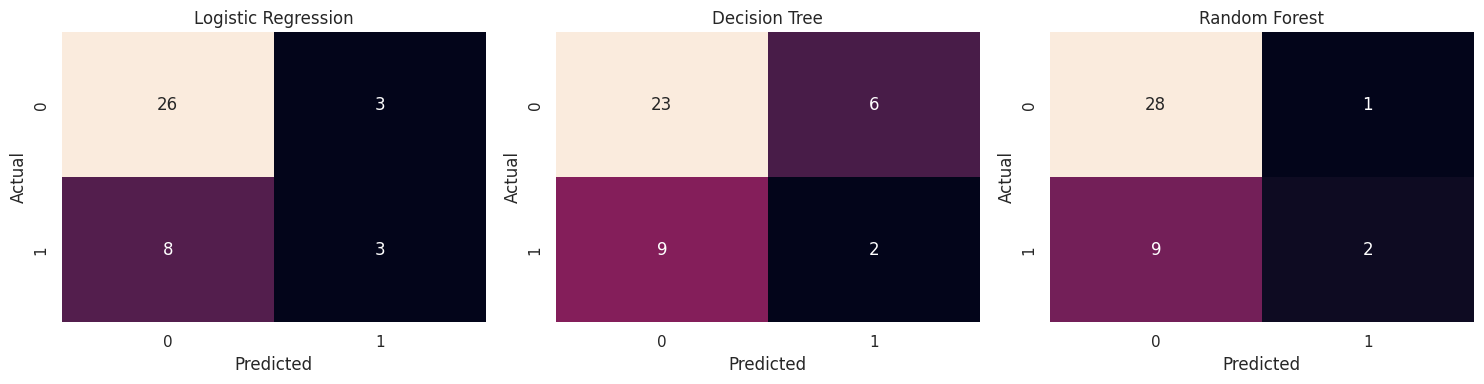

In [89]:
# ==========================================================
# Topic: Visualizing Confusion Matrices
# Description:
# The three confusion matrices are displayed as heatmaps.
# The values show how many test customers fall into each actual/predicted combination.
#
# Key idea:
# A heatmap makes the classification results easier to read visually.
# ==========================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name, cm in zip(
    axes,
    ["Logistic Regression", "Decision Tree", "Random Forest"],
    [cm_logistic, cm_tree, cm_forest]
):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cbar=False,
        ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


## 19. Feature importance — Random Forest


Feature importance tells us which transformed features the Random Forest relied on more heavily. It does not prove causation.


### 19.1 Get the feature names and importance values


In [90]:
# ==========================================================
# Topic: Random Forest Feature Importance
# Description:
# Feature importance shows how much each transformed feature contributed to the Random Forest's decision process.
# It is a model-based measure and does not prove that a feature causes Churn.
#
# Key idea:
# Feature importance helps us identify which inputs the trained Random Forest relied on more heavily.
# ==========================================================

rf_preprocessor = forest_clf_model.named_steps["preprocessor"]

rf_model = forest_clf_model.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()

importances = rf_model.feature_importances_

print("Number of transformed features:", len(feature_names))


Number of transformed features: 25


### 19.2 Create the feature-importance table


In [91]:
# ==========================================================
# Topic: Creating the Feature Importance Table
# Description:
# The transformed feature names are combined with their importance values.
# The table is sorted so the most important features appear first.
#
# Key idea:
# Sorting the values makes the strongest model-based feature contributions easier to inspect.
# ==========================================================

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    "Importance",
    ascending=False
).head(15)

display(importance_df)


,Feature,Importance
24,remainder__Days_Since_Last_Purchase,0.179877
21,remainder__Cart_Abandonment_Rate,0.096681
19,remainder__Avg_Order_Value,0.093990
17,remainder__Visits_Per_Month,0.093694
15,remainder__Income,0.074733
16,remainder__Tenure_Months,0.068780
14,remainder__Age,0.066815
20,remainder__Discount_Usage_Rate,0.060883
18,remainder__Products_Bought,0.052665
23,remainder__Support_Tickets,0.041928


### 19.3 Plot the top features


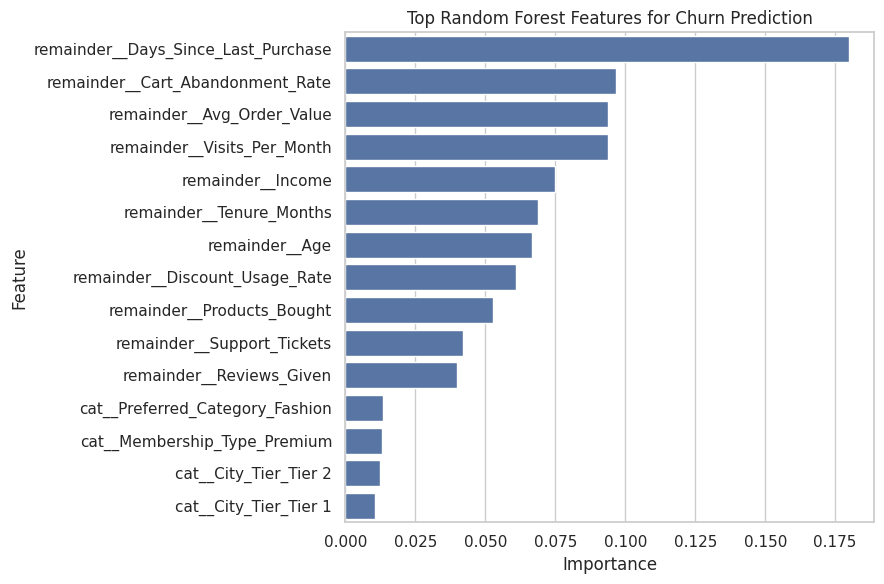

In [93]:
# ==========================================================
# Topic: Plotting Feature Importance
# Description:
# A bar chart displays the top 15 features ranked by Random Forest importance.
#
# Key idea:
# A visual ranking makes the model's feature importance easier to understand.
# ==========================================================

plt.figure(figsize=(9, 6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Top Random Forest Features for Churn Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 22. Student Mini-Challenge

Try these tasks without looking at the previous outputs first:

### Challenge 1 - Regression

# 20. Interactive student prediction


Students can copy one customer, change values, and see how the trained Random Forest models respond.


### 20.1 Select one customer


In [95]:
# ==========================================================
# Topic: Selecting a Sample Customer
# Description:
# The first customer is copied into a one-row DataFrame.
# This customer will be used for an interactive prediction experiment.
#
# Key idea:
# Students can modify this customer and observe how the model responds.
# ==========================================================

sample_customer = df[regression_features].iloc[[0]].copy()

display(sample_customer)


,Age,Gender,City_Tier,Income,Tenure_Months,Visits_Per_Month,Products_Bought,Avg_Order_Value,Discount_Usage_Rate,Cart_Abandonment_Rate,Reviews_Given,Support_Tickets,Days_Since_Last_Purchase,Membership_Type,Preferred_Category
0,22,Female,Tier 3,101500,104,4.2,13,4300,0.119,0.668,6,4,69,Basic,Electronics


### 20.2 Predict annual spending


In [96]:
# ==========================================================
# Topic: Predicting Annual Spending for One Customer
# Description:
# The trained Random Forest Regressor receives the sample customer's features.
# It returns a predicted Annual_Spending value.
#
# Key idea:
# A trained model can be used to make predictions for new individual customers.
# ==========================================================

predicted_spending = forest_reg_model.predict(sample_customer)[0]

print(f"Predicted annual spending: ₹{predicted_spending:,.0f}")


Predicted annual spending: ₹48,025


### 20.3 Predict churn probability


In [97]:
# ==========================================================
# Topic: Predicting Churn Probability
# Description:
# predict_proba() returns the probability for each class.
# The second probability, index 1, represents the probability of Churn.
#
# Key idea:
# The model gives a probability rather than only a yes/no answer.
# ==========================================================

predicted_churn_probability = forest_clf_model.predict_proba(
    sample_customer
)[0, 1]

print(f"Predicted churn probability: {predicted_churn_probability:.1%}")


Predicted churn probability: 71.1%


### 20.4 Student experiment


In [98]:
# ==========================================================
# Topic: Student Prediction Experiment
# Description:
# A copy of the sample customer is created and one value is changed.
# The modified customer is then sent through both trained models.
#
# Key idea:
# Changing one input and observing the prediction helps students understand how model inputs affect outputs.
# ==========================================================

student_customer = sample_customer.copy()

student_customer["Days_Since_Last_Purchase"] = 60

print("Modified customer:")
display(student_customer)

print(
    f"Predicted spending: ₹{forest_reg_model.predict(student_customer)[0]:,.0f}"
)

print(
    f"Predicted churn probability: "
    f"{forest_clf_model.predict_proba(student_customer)[0, 1]:.1%}"
)


Modified customer:


,Age,Gender,City_Tier,Income,Tenure_Months,Visits_Per_Month,Products_Bought,Avg_Order_Value,Discount_Usage_Rate,Cart_Abandonment_Rate,Reviews_Given,Support_Tickets,Days_Since_Last_Purchase,Membership_Type,Preferred_Category
0,22,Female,Tier 3,101500,104,4.2,13,4300,0.119,0.668,6,4,60,Basic,Electronics


Predicted spending: ₹47,676
Predicted churn probability: 63.1%


# 22. Student Mini-Challenge

Try these tasks without looking at the previous outputs first:

### Challenge 1 — Regression
Change the customer's:
- `Visits_Per_Month`
- `Avg_Order_Value`
- `Products_Bought`

Then observe how predicted annual spending changes.

### Challenge 2 — Classification
Increase:
- `Days_Since_Last_Purchase`
- `Cart_Abandonment_Rate`
- `Support_Tickets`

Then observe how the churn probability changes.

### Challenge 3 — Model comparison
Explain in your own words:
- Why might Linear Regression behave differently from a Decision Tree?
- Why does Random Forest contain many trees?
- Why can accuracy alone be misleading for churn prediction?

### Challenge 4 — Business interpretation
Answer:
> Which customer characteristics appear associated with higher spending or higher churn **in this synthetic dataset**?

Do not claim that these relationships prove causation.

# 24. Final Takeaways

By completing this notebook, students have followed an end-to-end supervised ML workflow:

**Business Question → Dataset → Features & Target → Train/Test Split → Model → Prediction → Evaluation → Interpretation**

### Regression
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- MAE, RMSE, R²

### Classification
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix

### Good ML practice
- Do not use the target as an input feature.
- Keep the test set separate.
- Avoid data leakage.
- Understand the metric you are using.
- Remember that synthetic educational data is not real-world evidence.

## 24. Final dataset verification


In [99]:
# ==========================================================
# Topic: Final Dataset Checks
# Description:
# These checks confirm the basic requirements of the workshop dataset.
# We verify the number of rows, columns, missing values, duplicate rows, and unique customer IDs.
#
# Key idea:
# A quick verification step helps confirm that the correct dataset is being used.
# ==========================================================

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("Unique customer IDs:", int(df["Customer_ID"].nunique()))


Rows: 200
Columns: 18
Missing values: 55
Duplicate rows: 0
Unique customer IDs: 200


In [100]:
# ==========================================================
# Topic: Dataset Verification with Assertions
# Description:
# assert checks whether the dataset satisfies the expected conditions.
# If a condition is false, Python stops and reports the failed assertion.
#
# Key idea:
# Assertions can automatically verify important assumptions before continuing.
# ==========================================================

# Drop rows with any missing values to ensure the dataset is 'clean' as per the workshop description.
df.dropna(inplace=True)

assert df.shape == (145, 18)
assert df.isna().sum().sum() == 0
assert df.duplicated().sum() == 0
assert df["Customer_ID"].nunique() == 145

print("Dataset verification PASSED!")

Dataset verification PASSED!
